# Plotting With Series

### Loading Libraries

In [1]:
# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

#### Retreiving Data

In [2]:
url = 'https://github.com/mattharrison/datasets'+\
    '/raw/master/data/alta-noaa-1980-2019.csv'

alta_df = pd.read_csv(url, dtype_backend='pyarrow')

In [3]:
dates = pd.to_datetime(alta_df.DATE)

In [4]:
snow = (alta_df
    .SNOW
    .rename(dates)
    )

In [5]:
snow

1980-01-01    2.0
1980-01-02    3.0
1980-01-03    1.0
1980-01-04    0.0
1980-01-05    0.0
             ... 
2019-09-03    0.0
2019-09-04    0.0
2019-09-05    0.0
2019-09-06    0.0
2019-09-07    0.0
Name: SNOW, Length: 14160, dtype: double[pyarrow]

#### Histograms

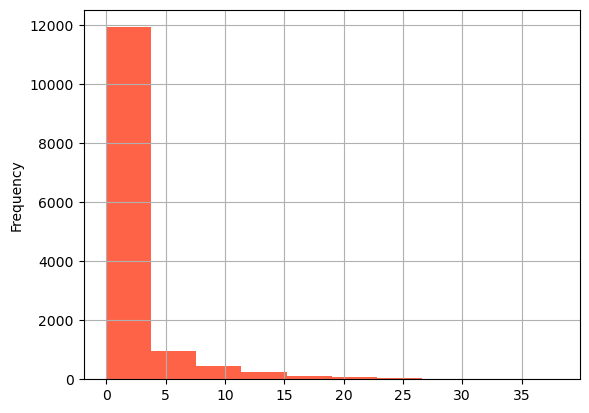

In [11]:
snow.plot.hist(color='tomato')

plt.grid(True)
plt.show()

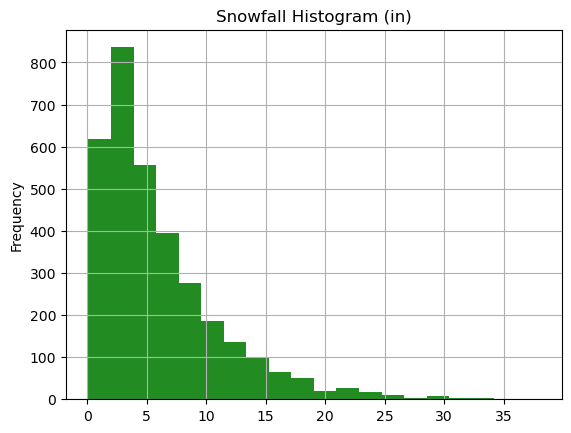

In [14]:
#Dropping entries
snow[snow>0].plot.hist(bins=20, title='Snowfall Histogram (in)', color='forestgreen')

plt.grid(True)
plt.show()

#### Box Plot

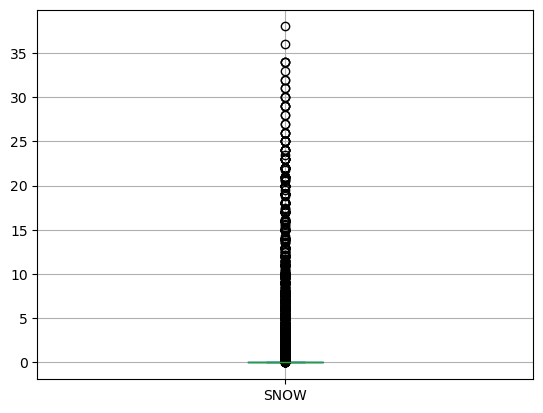

In [17]:
snow.plot.box()

plt.grid(True)
plt.show()

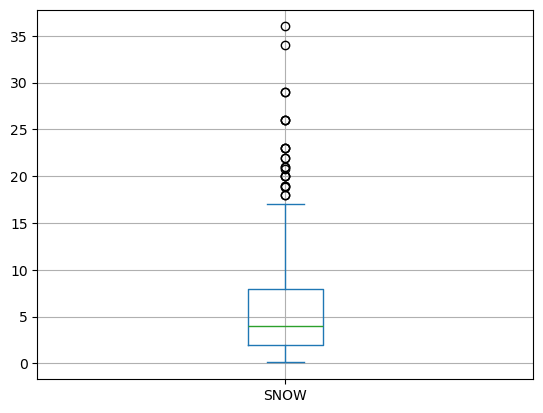

In [21]:
(snow
    [lambda s:(s.index.month == 1) & (s > 0)]
    .plot.box()
)

plt.grid(True)
plt.show()

#### Kernel Density Estimation Plot (`KDE`)

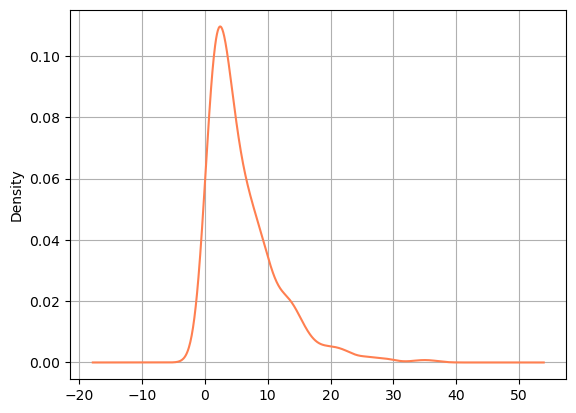

In [26]:
(snow
    [lambda s:(s.index.month == 1) & (s > 0)]
    .plot.kde(color='coral')
)

plt.grid(True)
plt.show()

#### Line Plots

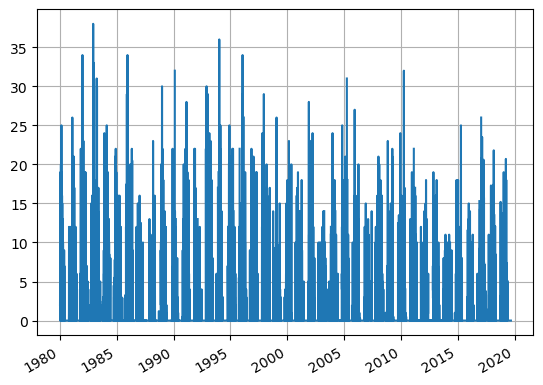

In [28]:
snow.plot.line()

plt.grid(True)
plt.show()

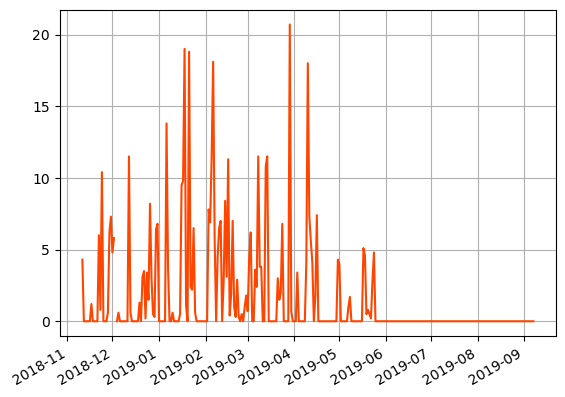

In [32]:
(snow
    .tail(300)
    .plot.line(color='orangered')
)

plt.grid(True)
plt.show()

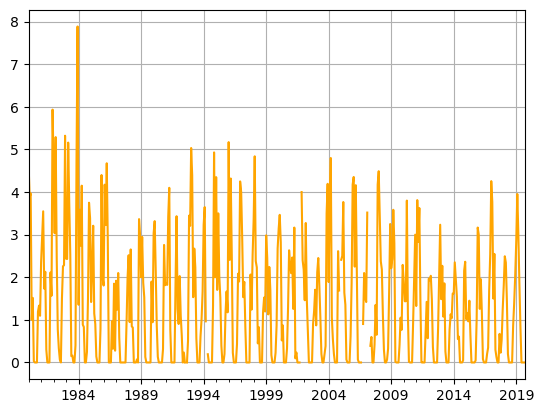

In [35]:
(snow
    .resample('ME')
    .mean()
    .plot.line(color='orange')
)

plt.grid(True)
plt.show()

#### Line Plots with Multiple Aggregations

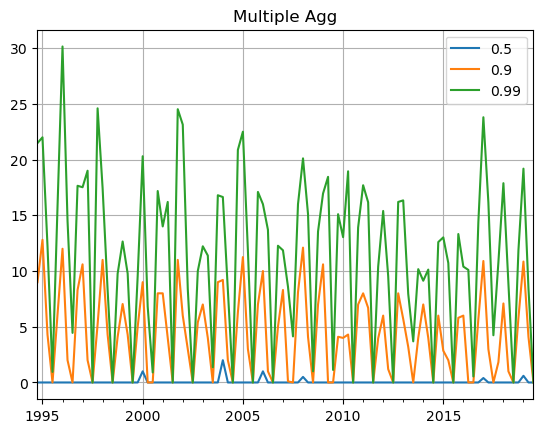

In [40]:
(snow
    .resample('QE')
    .quantile([.5, .9, .99])
    .unstack()
    .tail(100)
    .plot.line()
)

plt.title('Multiple Agg')
plt.grid(True)
plt.show()

#### Bar Plots

In [42]:
season2017 = (snow.loc['2016-10' : '2017-05'])

In [43]:
(season2017
    .resample('ME')
    .sum()
    .div(season2017.sum())
    .mul(100)
    .rename(lambda idx: idx.month_name())
)

October      2.153969
November     9.772637
December    15.715995
January     25.468688
February    21.041085
March        9.274033
April       14.738732
May          1.834862
Name: SNOW, dtype: double[pyarrow]

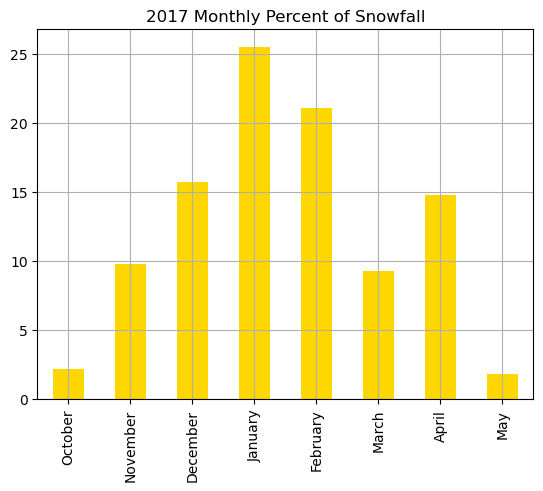

In [45]:
(season2017
    .resample('ME')
    .sum()
    .div(season2017.sum())
    .mul(100)
    .rename(lambda idx: idx.month_name())
    .plot.bar(title='2017 Monthly Percent of Snowfall', color='gold')
)

plt.grid(True)
plt.show()

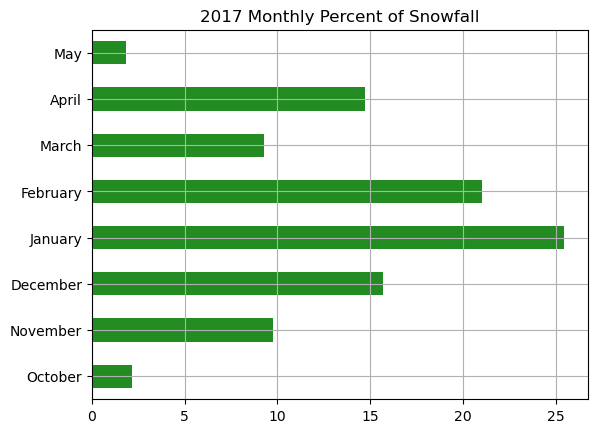

In [46]:
(season2017
    .resample('ME')
    .sum()
    .div(season2017.sum())
    .mul(100)
    .rename(lambda idx: idx.month_name())
    .plot.barh(title='2017 Monthly Percent of Snowfall', color='forestgreen')
)

plt.grid(True)
plt.show()

In [47]:
url = 'https://github.com/mattharrison/datasets/raw/master/data/' \
      'vehicles.csv.zip'

In [48]:
df = pd.read_csv(url, dtype_backend='pyarrow')

In [49]:
make = df.make

In [50]:
make.value_counts()

make
Chevrolet                           4003
Ford                                3371
Dodge                               2583
GMC                                 2494
Toyota                              2071
                                    ... 
Grumman Allied Industries              1
Environmental Rsch and Devp Corp       1
General Motors                         1
Goldacre                               1
Isis Imports Ltd                       1
Name: count, Length: 136, dtype: int64[pyarrow]

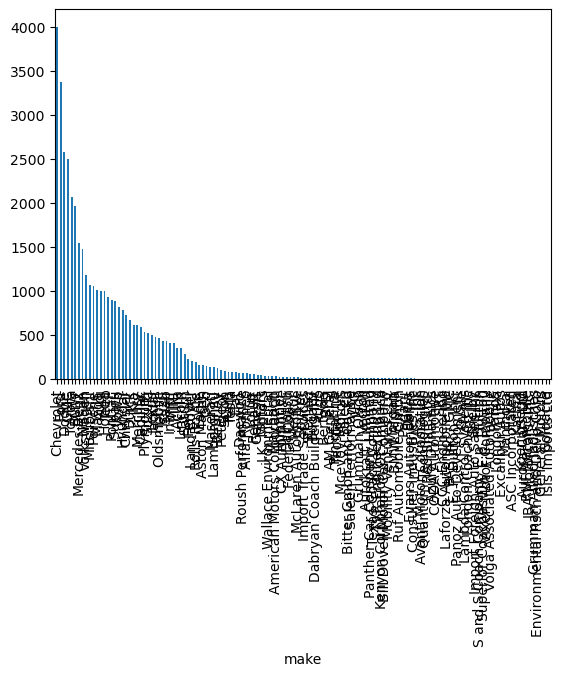

In [53]:
(make
    .value_counts()
    .plot.bar()
)

# plt.grid(True)
plt.show()

In [54]:
top10 = make.value_counts().index[:10]

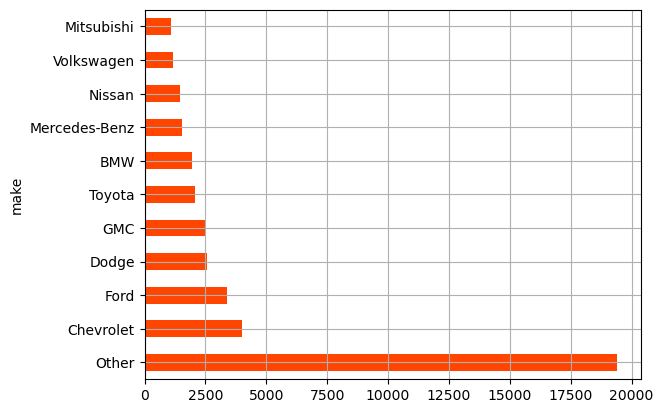

In [59]:
(make
    .where(make.isin(top10), 'Other')
    .value_counts()
    .plot.barh(color='orangered'))

plt.grid(True)
plt.show()

#### Styling

In [64]:
with sns.plotting_context(rc=dict(font='Roboto', palette=color_palette)):
    fig, ax = plt.subplots(dpi=600, figsize=(10, 4))
    snow.plot.hist()
    sns.despine()
    fig.savefig('snowhist.png', dpi=600, bbox_inches='tight')